# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.12.12 | pandas 3.0.6 | seaborn 0.13.2


In [2]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [3]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    missing = frame.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    return pd.DataFrame({
        "missing": missing.astype(int),
        "percent": (100 * missing / len(frame)).round(2),
    })

In [4]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [5]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    ordered = frame.sort_values(sort_column, ascending=False)
    return ordered.iloc[0], ordered.loc[label]

In [6]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Ward, Miss. Anna | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [7]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    filled = frame.copy()
    group_median = filled.groupby(["Pclass", "Sex"])["Age"].transform("median")
    filled["Age"] = filled["Age"].fillna(group_median)
    return filled

In [8]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [9]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    values = frame[column]
    strategies = {
        "dropna": values.dropna(),
        "mean": values.fillna(values.mean()),
        "median": values.fillna(values.median()),
        "group_median": values.fillna(frame.groupby(["Pclass", "Sex"])[column].transform("median")),
    }
    return pd.DataFrame({
        name: {"n": s.count(), "mean": s.mean(), "median": s.median(), "std": s.std()}
        for name, s in strategies.items()
    }).T[["n", "mean", "median", "std"]]

In [10]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

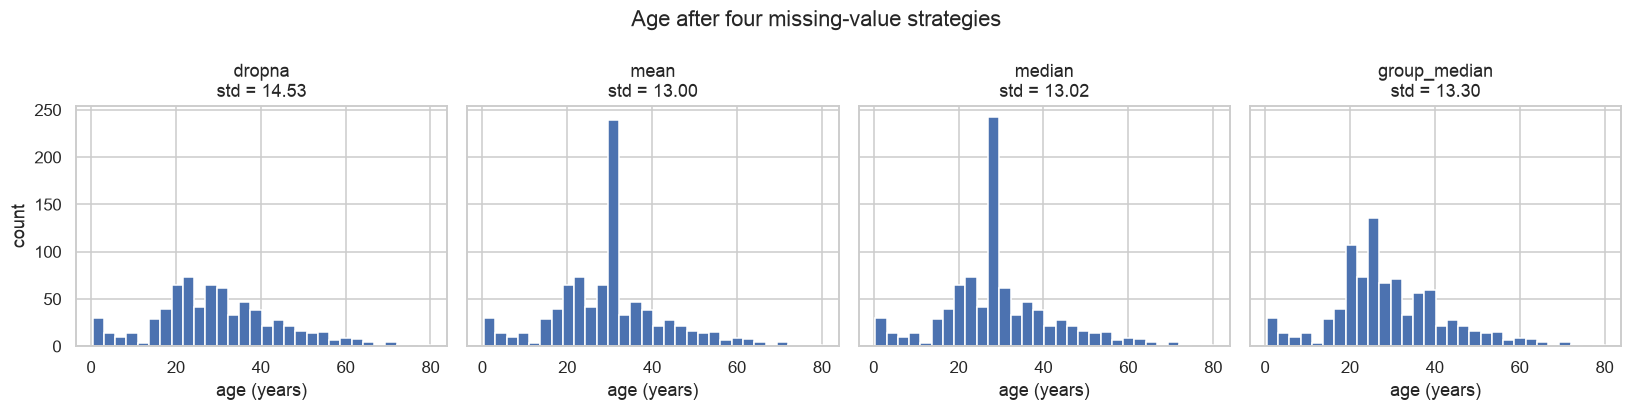

std loss vs dropna: mean fill 1.5245, median fill 1.5068, group fill 1.2221
rows sitting exactly on the fill value: 177 (mean fill), 202 (median fill)

share of Age missing by Pclass:
Pclass
1   0.1389
2   0.0598
3   0.2770

share of Age missing by Sex:
Sex
female   0.1688
male     0.2149

survival rate, Age recorded vs missing:
age_missing
False   0.4062
True    0.2938

median recorded age by (Pclass, Sex):
Sex     female    male
Pclass                
1      35.0000 40.0000
2      28.0000 30.0000
3      21.5000 25.0000


In [11]:
_age = titanic["Age"]
_age_strategies = {
    "dropna": _age.dropna(),
    "mean": _age.fillna(_age.mean()),
    "median": _age.fillna(_age.median()),
    "group_median": fill_age_by_group(titanic)["Age"],
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharex=True, sharey=True)
for ax, (name, values) in zip(axes, _age_strategies.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name}\nstd = {values.std():.2f}")
    ax.set_xlabel("age (years)")
axes[0].set_ylabel("count")
fig.suptitle("Age after four missing-value strategies")
fig.tight_layout()
plt.show()

print(f"std loss vs dropna: mean fill {_comparison.loc['dropna', 'std'] - _comparison.loc['mean', 'std']:.4f}, "
      f"median fill {_comparison.loc['dropna', 'std'] - _comparison.loc['median', 'std']:.4f}, "
      f"group fill {_comparison.loc['dropna', 'std'] - _comparison.loc['group_median', 'std']:.4f}")
print("rows sitting exactly on the fill value:",
      int((_age_strategies["mean"] == _age.mean()).sum()), "(mean fill),",
      int((_age_strategies["median"] == _age.median()).sum()), "(median fill)")

_age_missing = titanic.assign(age_missing=_age.isna())
print("\nshare of Age missing by Pclass:")
print(_age_missing.groupby("Pclass")["age_missing"].mean().round(4).to_string())
print("\nshare of Age missing by Sex:")
print(_age_missing.groupby("Sex")["age_missing"].mean().round(4).to_string())
print("\nsurvival rate, Age recorded vs missing:")
print(_age_missing.groupby("age_missing")["Survived"].mean().round(4).to_string())
print("\nmedian recorded age by (Pclass, Sex):")
print(titanic.groupby(["Pclass", "Sex"])["Age"].median().unstack().to_string())

**Your answer:**

**(a)** Filling with the mean keeps the mean at exactly 29.6991, the same as `dropna`, but it damages the spread. The standard deviation drops from 14.5265 to 13.0020, so it loses 1.52 years, about 10 %. In the histogram all 177 filled passengers sit on one value (29.70), which makes a tall artificial spike in the middle of the distribution. Keeping the mean does not make the fill harmless, because the mean is only one summary. Anything that depends on the spread or the shape gets distorted: standard errors look smaller than they are, correlations with age get weaker, and a model will treat the spike as a real group of 177 passengers who are exactly 29.7 years old. The median fill does the same thing (std 13.0197, and 202 rows now sit on 28.0).

**(b)** Dropping the 177 rows is only unbiased if age is MCAR, meaning that whether an age is missing has nothing to do with anything else. That is not plausible for Titanic. The share of missing ages depends strongly on class: 13.9 % in first, 6.0 % in second and 27.7 % in third. It also depends on sex (21.5 % of men against 16.9 % of women) and it is linked to the outcome: survival is 40.6 % among passengers with a recorded age and only 29.4 % among those without. Since missingness is explained by columns we can see (mostly `Pclass`), I would call it MAR. It could also be partly MNAR, because the ages of third-class passengers who died were probably less likely to be recorded at all, but that cannot be checked from the data. Either way, `dropna` removes mostly third-class passengers and non-survivors, so the remaining sample is biased towards first class and survivors.

**(c)** I would use the group median by (Pclass, Sex). Missingness depends on class and sex, and the recorded ages also differ a lot between these groups (the median goes from 40 for first-class men down to 21.5 for third-class women), so filling within the group uses exactly the information that explains the gaps instead of one global number. It still shrinks the spread, but less than a constant fill (std 13.3044 against 13.0020), it keeps all 891 rows, and I would add a flag column `age_missing` so that a model can still use the fact that the age was missing.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [12]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    q1, q3 = float(series.quantile(0.25)), float(series.quantile(0.75))
    iqr = q3 - q1
    lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
    mask = (series < lower) | (series > upper)
    return {"q1": q1, "q3": q3, "lower": lower, "upper": upper, "mask": mask}

In [13]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [14]:
def _sigma_count(series):
    return int((np.abs(series - series.mean()) > 3 * series.std()).sum())

for column in ["Fare", "Age"]:
    values = titanic[column]
    print(f"{column}: mean {values.mean():.2f}  median {values.median():.2f}  std {values.std():.2f}  "
          f"skew {values.skew():.2f}  max {values.max():.2f}")
    rows = []
    for m in [1.0, 1.5, 3.0, 5.0]:
        result = iqr_outliers(values, m)
        rows.append((f"IQR x {m}", f"[{result['lower']:.2f}, {result['upper']:.2f}]", int(result["mask"].sum())))
    rows.append(("3 sigma", f"[{values.mean() - 3 * values.std():.2f}, {values.mean() + 3 * values.std():.2f}]",
                 _sigma_count(values)))
    print(pd.DataFrame(rows, columns=["rule", "fences", "flagged"]).to_string(index=False))
    print()

_fare_flagged = titanic[iqr_outliers(titanic["Fare"])["mask"]]
print("Fare flagged by 1.5 x IQR, by Pclass:", _fare_flagged["Pclass"].value_counts().sort_index().to_dict())
print(f"survival among flagged fares {_fare_flagged['Survived'].mean():.4f} vs overall {titanic['Survived'].mean():.4f}")
print("median fare by Pclass:", titanic.groupby("Pclass")["Fare"].median().round(2).to_dict())
print("fares of exactly 0:", int((titanic["Fare"] == 0).sum()),
      "| by Pclass:", titanic.loc[titanic["Fare"] == 0, "Pclass"].value_counts().sort_index().to_dict())
print(f"std of Fare with and without the 116 flagged: {titanic['Fare'].std():.2f} vs "
      f"{titanic.loc[~iqr_outliers(titanic['Fare'])['mask'], 'Fare'].std():.2f}")

Fare: mean 32.20  median 14.45  std 49.69  skew 4.79  max 512.33
     rule            fences  flagged
IQR x 1.0   [-15.18, 54.09]      141
IQR x 1.5   [-26.72, 65.63]      116
IQR x 3.0  [-61.36, 100.27]       53
IQR x 5.0 [-107.54, 146.45]       31
  3 sigma [-116.88, 181.28]       20

Age: mean 29.70  median 28.00  std 14.53  skew 0.39  max 80.00
     rule           fences  flagged
IQR x 1.0    [2.25, 55.88]       63
IQR x 1.5   [-6.69, 64.81]       11
IQR x 3.0  [-33.50, 91.62]        0
IQR x 5.0 [-69.25, 127.38]        0
  3 sigma  [-13.88, 73.28]        2

Fare flagged by 1.5 x IQR, by Pclass: {1: 104, 2: 5, 3: 7}
survival among flagged fares 0.6810 vs overall 0.3838
median fare by Pclass: {1: 60.29, 2: 14.25, 3: 8.05}
fares of exactly 0: 15 | by Pclass: {1: 5, 2: 6, 3: 4}
std of Fare with and without the 116 flagged: 49.69 vs 13.58


**Your answer:**

**(a)** Counts on `Fare`:

| rule | fences | flagged |
|---|---|---|
| IQR × 1.0 | [-15.18, 54.09] | 141 |
| IQR × 1.5 | [-26.72, 65.63] | 116 |
| IQR × 3.0 | [-61.36, 100.27] | 53 |
| IQR × 5.0 | [-107.54, 146.45] | 31 |
| 3σ | [-116.88, 181.28] | 20 |

**(b)** `Fare` is very right-skewed: the mean is 32.20, but the median is only 14.45, the skewness is 4.79 and the maximum is 512.33. The IQR rule is built from Q1 = 7.91 and Q3 = 31.00. Quartiles depend only on the middle half of the data, so the expensive tickets do not move them, and the upper fence stays at 65.63, which flags the whole first-class tail (116 fares). The 3σ rule uses the mean and the standard deviation, and both are pulled up by those same expensive fares. The standard deviation is 49.69 with all fares, but only 13.58 once the 116 flagged fares are left out. So the large values inflate the SD, the threshold moves out to 181.28, and most of them end up inside it. The 3σ rule is the one inflated by the points it is trying to detect, and even at a multiplier of 5 the IQR rule still flags more (31 against 20).

**(c)** On `Age` the two rules are much closer: 11 points at IQR × 1.5 against 2 with 3σ, and 0 at IQR × 3 and × 5. `Age` is almost symmetric (skewness 0.39, mean 29.70 and median 28.00 are close) and has no long tail, so the mean and SD describe it reasonably well and the few old passengers do not inflate the SD much. The two rules only disagree strongly when the distribution is skewed.

**(d)** I would not remove the high fares. 104 of the 116 flagged fares are first-class tickets (the median first-class fare is 60.29, compared with 8.05 in third). These are real prices for the best cabins, and these passengers survived at 68.1 % against 38.4 % overall, so removing them would remove part of the effect we want to study. If anything in this column is suspicious, it is at the other end: 15 fares are exactly 0, spread over all three classes (5, 6 and 4). That looks like a recording convention (crew, guests or an unknown price) rather than a real ticket price, and those are the values I would check and possibly treat as missing.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [15]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    a, b = frame[column_a], frame[column_b]
    pearson = float(a.corr(b, method="pearson"))
    spearman = float(a.corr(b, method="spearman"))
    return {"pearson": pearson, "spearman": spearman, "difference": pearson - spearman}

In [16]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

curved pair            : pearson +0.8605  spearman +0.9653  difference -0.1048
color_intensity vs hue : pearson -0.5218  spearman -0.4185  difference -0.1033


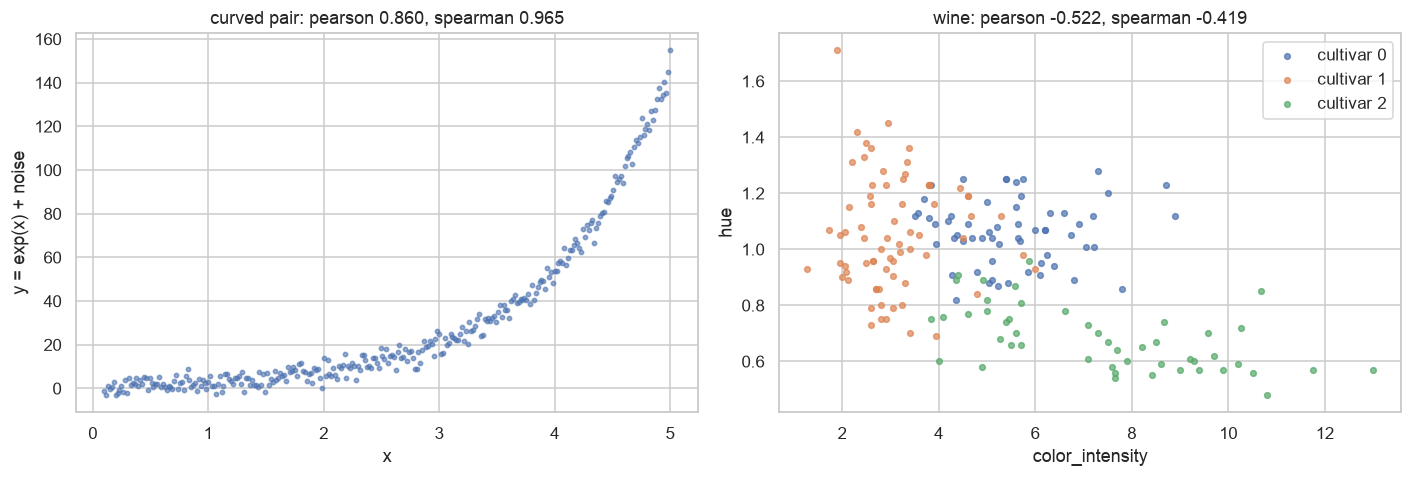


color_intensity vs hue within each cultivar:
  cultivar 0: n  59  pearson +0.0282  spearman -0.0182
  cultivar 1: n  71  pearson -0.0261  spearman +0.0284
  cultivar 2: n  48  pearson -0.5686  spearman -0.5820

five largest color_intensity values:
     color_intensity    hue  target
158          13.0000 0.5700       2
159          11.7500 0.5700       2
151          10.8000 0.4800       2
166          10.6800 0.8500       2
153          10.5200 0.5600       2


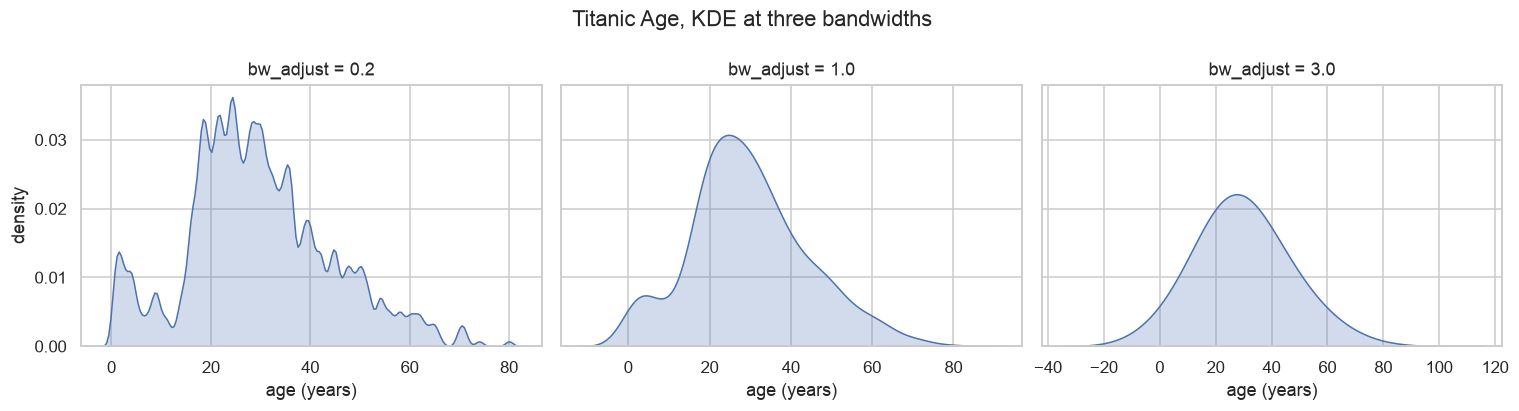

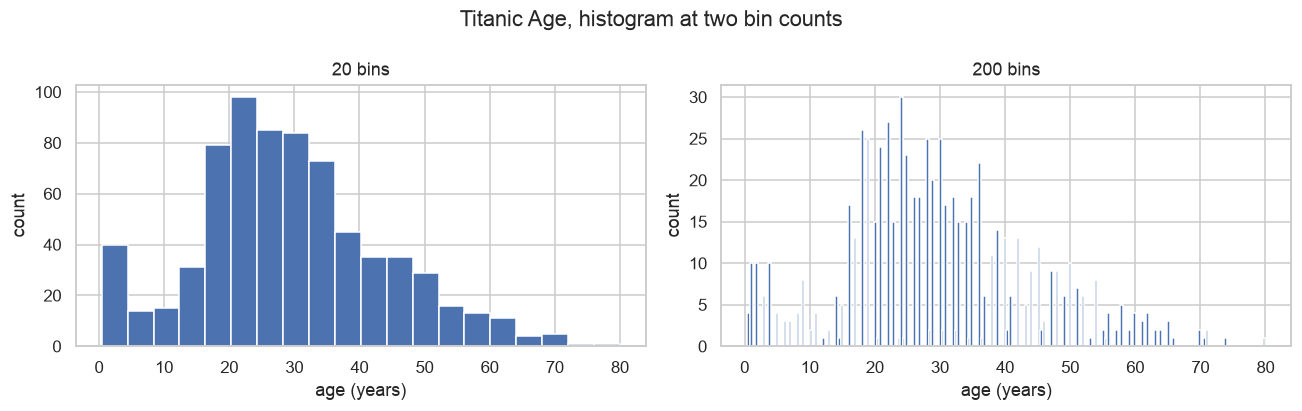

recorded ages: 714, whole numbers 96.50%, ending in .5: 18, below 1: 7
most common ages: {24.0: 30, 22.0: 27, 18.0: 26, 28.0: 25, 19.0: 25, 30.0: 25}
ages that are multiples of 5 (age >= 20): 23.27% vs 20.00% if uniform


In [17]:
_color_hue = correlation_pair(wine, "color_intensity", "hue")
print(f"curved pair            : pearson {_c['pearson']:+.4f}  spearman {_c['spearman']:+.4f}  "
      f"difference {_c['difference']:+.4f}")
print(f"color_intensity vs hue : pearson {_color_hue['pearson']:+.4f}  spearman {_color_hue['spearman']:+.4f}  "
      f"difference {_color_hue['difference']:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(_curved["x"], _curved["y"], s=8, alpha=0.6)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y = exp(x) + noise")
axes[0].set_title(f"curved pair: pearson {_c['pearson']:.3f}, spearman {_c['spearman']:.3f}")
for target, group in wine.groupby("target"):
    axes[1].scatter(group["color_intensity"], group["hue"], s=14, alpha=0.7, label=f"cultivar {target}")
axes[1].set_xlabel("color_intensity")
axes[1].set_ylabel("hue")
axes[1].set_title(f"wine: pearson {_color_hue['pearson']:.3f}, spearman {_color_hue['spearman']:.3f}")
axes[1].legend()
fig.tight_layout()
plt.show()

print("\ncolor_intensity vs hue within each cultivar:")
for target, group in wine.groupby("target"):
    pair = correlation_pair(group, "color_intensity", "hue")
    print(f"  cultivar {target}: n {len(group):3d}  pearson {pair['pearson']:+.4f}  spearman {pair['spearman']:+.4f}")
_top_color = wine.nlargest(5, "color_intensity")[["color_intensity", "hue", "target"]]
print("\nfive largest color_intensity values:")
print(_top_color.to_string())

_ages = titanic["Age"].dropna()
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, adjust in zip(axes, [0.2, 1.0, 3.0]):
    sns.kdeplot(x=_ages, bw_adjust=adjust, fill=True, ax=ax)
    ax.set_title(f"bw_adjust = {adjust}")
    ax.set_xlabel("age (years)")
axes[0].set_ylabel("density")
fig.suptitle("Titanic Age, KDE at three bandwidths")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, bins in zip(axes, [20, 200]):
    ax.hist(_ages, bins=bins)
    ax.set_title(f"{bins} bins")
    ax.set_xlabel("age (years)")
    ax.set_ylabel("count")
fig.suptitle("Titanic Age, histogram at two bin counts")
fig.tight_layout()
plt.show()

_whole = (_ages == _ages.round()).mean()
_half = ((_ages % 1) == 0.5).sum()
print(f"recorded ages: {len(_ages)}, whole numbers {_whole:.2%}, ending in .5: {_half}, below 1: {(_ages < 1).sum()}")
print("most common ages:", _ages.value_counts().head(6).to_dict())
print("ages that are multiples of 5 (age >= 20):",
      f"{(_ages[_ages >= 20] % 5 == 0).mean():.2%} vs 20.00% if uniform")

**Your answer:**

**(a)** On the curved pair Pearson is 0.8605 and Spearman 0.9653, a gap of 0.105. Pearson measures how well the points fit a straight line. Spearman ranks both variables first and measures how consistently y goes up when x goes up, whatever the shape. In the scatter plot y is almost flat for x < 2 and then shoots up to about 150, so the relationship is perfectly monotonic but not linear at all. The ranks follow each other almost exactly, so Spearman is close to 1. A straight line misses the flat part and the steep part, so Pearson is lower. If I were going to fit a linear model to this pair, I would report Pearson, because that is the one that describes how well a straight line will work. A high Spearman would make the linear fit look better than it is. It would also be a sign to transform y first (e.g. log), since the relationship is exponential.

**(b)** `color_intensity` against `hue`: Pearson -0.5218, Spearman -0.4185. Here Pearson is the stronger one, the opposite of the curved pair. The scatter plot coloured by cultivar explains why. Inside cultivars 0 and 1 there is almost no relationship (Pearson +0.03 and -0.03). Most of the association comes from cultivar 2, which has both high colour intensity (the five highest values, 10.5 to 13.0, all belong to it) and low hue (around 0.5 to 0.85). These extreme points at the bottom right carry a lot of weight in Pearson, because it uses the actual distances from the mean. In ranks, they are just "the largest few", so their influence is smaller. The gap therefore comes from a few extreme points belonging to one group, not from a curved shape.

**(c)** The bin count and the KDE bandwidth are the same decision: how much you smooth, i.e. over how wide a window neighbouring points get averaged. A large window (few bins, or `bw_adjust=3.0`) hides real structure. At 3.0 the curve becomes one smooth bell, the small peak of young children around 0 to 5 years disappears, and the curve even extends below 0 and above 100 years. A small window (200 bins, or `bw_adjust=0.2`) invents structure: the curve has many narrow spikes around 20 to 40 years that are not real features of the passengers. The clearest artifact is this comb of spikes: 96.5 % of the recorded ages are whole numbers, and there are some typical rounded values (24 years appears 30 times, 22 appears 27 times), so the density is concentrated on integers. It shows how ages were written down (rounded to full years, some as estimates like xx.5), not how old the passengers actually were. The middle setting (`bw_adjust=1.0`, or 20 bins) shows the real features: a small bump of children and a main group of passengers in their twenties with a long tail to 80.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [18]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    categories = sorted(series.unique())
    label = {category: code for code, category in enumerate(categories)}
    onehot = pd.get_dummies(pd.Series(categories, index=categories), dtype=float)
    rows = {
        f"{a}|{b}": {
            "label_distance": float(abs(label[a] - label[b])),
            "onehot_distance": float(np.linalg.norm(onehot.loc[a] - onehot.loc[b])),
        }
        for i, a in enumerate(categories)
        for b in categories[i + 1:]
    }
    return pd.DataFrame(rows).T[["label_distance", "onehot_distance"]].sort_index()

In [19]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [20]:
_renamed = _embarked.map({"Q": "A_Queenstown", "S": "B_Southampton", "C": "C_Cherbourg"})
print("original names:")
print(encoding_distances(_embarked).round(4).to_string())
print("\nrenamed so that alphabetical order is Queenstown, Southampton, Cherbourg:")
print(encoding_distances(_renamed).round(4).to_string())

print("\nsurvival rate and median fare by Pclass:")
print(titanic.groupby("Pclass").agg(survival=("Survived", "mean"), median_fare=("Fare", "median")).round(4).to_string())
print("\nsurvival rate and median fare by Embarked:")
print(titanic.groupby("Embarked").agg(survival=("Survived", "mean"), median_fare=("Fare", "median")).round(4).to_string())

original names:
     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

renamed so that alphabetical order is Queenstown, Southampton, Cherbourg:
                            label_distance  onehot_distance
A_Queenstown|B_Southampton          1.0000           1.4142
A_Queenstown|C_Cherbourg            2.0000           1.4142
B_Southampton|C_Cherbourg           1.0000           1.4142

survival rate and median fare by Pclass:
        survival  median_fare
Pclass                       
1         0.6296      60.2875
2         0.4728      14.2500
3         0.2424       8.0500

survival rate and median fare by Embarked:
          survival  median_fare
Embarked                       
C           0.5536      29.7000
Q           0.3896       7.7500
S           0.3370      13.0000


**Your answer:**

**(a)** If the ports are renamed so that alphabetical order becomes Queenstown, Southampton, Cherbourg, the codes become Q = 0, S = 1, C = 2. Now Q and C are 2 apart, while S is 1 from both. With the original names C and S were the pair 2 apart. So the same three ports get a different geometry only because of their names, and the one-hot distances stay √2 = 1.4142 in both cases. For a model that uses distances or a single coefficient per feature, this means the "similarity" between ports depends on the alphabet, which is not information about the ports at all. Two analysts with different spellings would get different models from the same data.

**(b)** The difference is that `Pclass` has a real order outside the encoding, and `Embarked` does not. First, second and third class are ordered by price (median fare 60.29, 14.25 and 8.05) and by survival (62.96 %, 47.28 % and 24.24 %), so 1 < 2 < 3 matches something true, and second class really is "between" the other two. Ports have no such order. Survival by port (C 55.4 %, Q 39.0 %, S 33.7 %) and median fare (C 29.70, Q 7.75, S 13.00) do not even put the ports in the same order, and nothing makes Southampton lie "between" Cherbourg and Queenstown. The integer codes for `Pclass` describe a real ordering. For `Embarked` they invent one.

**(c)** Tree-based models (decision trees, random forests). A tree splits one feature at a time with thresholds such as "code ≤ 0.5". With enough splits it can separate any category from the others, whatever number it was given, and it never uses distances between codes. A bad ordering can make a tree need a few extra splits, but it does not force a wrong geometry on the model the way it does for k-NN, SVM or linear regression.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    scaler = StandardScaler().fit(X_train)
    return {
        "X_train": scaler.transform(X_train),
        "X_test": scaler.transform(X_test),
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }

In [22]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

_Xw, _yw = wine[_features].values, wine["target"].values
_Xtr, _Xte, _ytr, _yte = train_test_split(_Xw, _yw, test_size=0.3, stratify=_yw, random_state=SEED)

for scaler_class in [StandardScaler, MinMaxScaler]:
    scaler = scaler_class().fit(_Xtr)
    train_scaled, test_scaled = scaler.transform(_Xtr), scaler.transform(_Xte)
    outside = ((test_scaled < 0) | (test_scaled > 1)).sum()
    print(f"{scaler_class.__name__:15s} train [{train_scaled.min():+.4f}, {train_scaled.max():+.4f}]  "
          f"test [{test_scaled.min():+.4f}, {test_scaled.max():+.4f}]  test cells outside [0, 1]: {outside}")

_mm = MinMaxScaler().fit(_Xtr)
_test_mm = _mm.transform(_Xte)
_col = np.unravel_index(np.argmax(_test_mm), _test_mm.shape)[1]
print(f"largest min-max test value is in '{_features[_col]}': test max {_Xte[:, _col].max():.2f} "
      f"vs train max {_Xtr[:, _col].max():.2f}")

_proline_idx = _features.index("proline")
_extreme = wine[_features].copy()
_extreme.loc[_extreme["proline"].idxmax(), "proline"] *= 50
_proline_raw = _extreme["proline"].values.reshape(-1, 1)
_is_extreme = _proline_raw.ravel() == _proline_raw.max()
print(f"\nproline max raised from {wine['proline'].max():.0f} to {_proline_raw.max():.0f}")
for name, original, disturbed in [
    ("StandardScaler", StandardScaler().fit_transform(wine[["proline"]].values),
     StandardScaler().fit_transform(_proline_raw)),
    ("MinMaxScaler", MinMaxScaler().fit_transform(wine[["proline"]].values),
     MinMaxScaler().fit_transform(_proline_raw)),
]:
    rest_before, rest_after = original.ravel()[~_is_extreme], disturbed.ravel()[~_is_extreme]
    print(f"{name:15s} other 177 wines: range before [{rest_before.min():+.4f}, {rest_before.max():+.4f}] "
          f"sd {rest_before.std():.4f}  ->  after [{rest_after.min():+.4f}, {rest_after.max():+.4f}] "
          f"sd {rest_after.std():.4f};  extreme point -> {disturbed.ravel()[_is_extreme][0]:.2f}")

_leaky_scaler = StandardScaler().fit(_Xw)
_honest_scaler = StandardScaler().fit(_Xtr)
print(f"\ntest mean of first 3 features, honest scaler: {_honest_scaler.transform(_Xte).mean(axis=0)[:3].round(4)}")
print(f"test mean of first 3 features, leaked scaler: {_leaky_scaler.transform(_Xte).mean(axis=0)[:3].round(4)}")
for name, scaler in [("honest", _honest_scaler), ("leaked", _leaky_scaler)]:
    accuracy = KNeighborsClassifier(n_neighbors=5).fit(scaler.transform(_Xtr), _ytr).score(scaler.transform(_Xte), _yte)
    print(f"5-NN test accuracy with {name} scaler: {accuracy:.4f}")

StandardScaler  train [-3.6570, +3.9167]  test [-2.5321, +4.7572]  test cells outside [0, 1]: 483
MinMaxScaler    train [+0.0000, +1.0000]  test [-0.0436, +1.1358]  test cells outside [0, 1]: 7
largest min-max test value is in 'magnesium': test max 162.00 vs train max 151.00

proline max raised from 1680 to 84000
StandardScaler  other 177 wines: range before [-1.4932, +2.5479] sd 0.9775  ->  after [-0.1495, +0.0542] sd 0.0493;  extreme point -> 13.29
MinMaxScaler    other 177 wines: range before [+0.0000, +0.9051] sd 0.2189  ->  after [+0.0000, +0.0152] sd 0.0037;  extreme point -> 1.00

test mean of first 3 features, honest scaler: [-0.0324  0.0259 -0.0291]
test mean of first 3 features, leaked scaler: [-0.0234  0.0182 -0.0204]
5-NN test accuracy with honest scaler: 0.9630
5-NN test accuracy with leaked scaler: 0.9630


**Your answer:**

**(a)** Using the same train/test split as Task 8:

| scaler | train min | train max | test min | test max |
|---|---|---|---|---|
| StandardScaler | -3.6570 | +3.9167 | -2.5321 | +4.7572 |
| MinMaxScaler | 0.0000 | 1.0000 | -0.0436 | +1.1358 |

With min-max, the training set lies exactly in [0, 1] by construction, but 7 test values fall outside it. The largest one is in `magnesium`: the test set has a wine with 162, while the highest value in the training set was 151. The scaler learned the min and max from the training data only, so a test value beyond that range gets mapped outside [0, 1]. This is correct, not a bug. The test set is supposed to behave like new data the model has not seen, and new data can be more extreme than anything in the training set. Forcing the test set into [0, 1] would require using the test set's own min and max, and that is leakage.

**(b)** After multiplying the largest `proline` value by 50 (1680 → 84 000), the other 177 wines are squeezed in both scalers, but min-max suffers more. With min-max, the extreme point becomes 1.0 and everything else is squeezed into [0, 0.0152] (sd 0.0037, before it was [0, 0.9051] with sd 0.2189). The max enters the formula directly as the denominator, so one point decides the scale for all the others. With the standard scaler the extreme point gets a z-score of 13.29, and the rest are squeezed into [-0.15, +0.05] (sd 0.0493 instead of 0.9775). Here the outlier acts through the mean and the SD, which it also inflates a lot, but it at least shows up as a clearly extreme z-score. Both scalers are sensitive to it, and min-max is completely defined by that one value.

**(c)** The leaked scaler was fitted on all 178 wines, including the 54 test wines, so the test set's means and variances went into the preprocessing. You can see it in the test means of the first three features: they are closer to 0 with the leaked scaler (-0.0234, 0.0182, -0.0204) than with the honest one (-0.0324, 0.0259, -0.0291). In my run, the 5-NN accuracy was the same both ways (0.9630), but if the leaked version had given a higher score, that extra accuracy would measure how much the model benefits from knowing the statistics of the test set in advance. It would not measure how well it predicts new wines. In a real deployment, the future data is not available when the scaler is fitted, so the extra accuracy would disappear, and the evaluation would have been too optimistic.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [24]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    if standardise:
        X = StandardScaler().fit_transform(X)
    cumulative = np.cumsum(PCA(random_state=SEED).fit(X).explained_variance_ratio_)
    needed = {t: int(np.argmax(cumulative >= t)) + 1 for t in thresholds}
    return {"cumulative": cumulative, "needed": needed}

In [25]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

unstandardised PC1 loadings, largest by magnitude:
proline             0.9998
magnesium           0.0179
alcalinity_of_ash   0.0047

variance of each raw feature, top 3:
proline             99,166.7200
magnesium              203.9900
alcalinity_of_ash       11.1500
proline share of total raw variance: 99.7738%


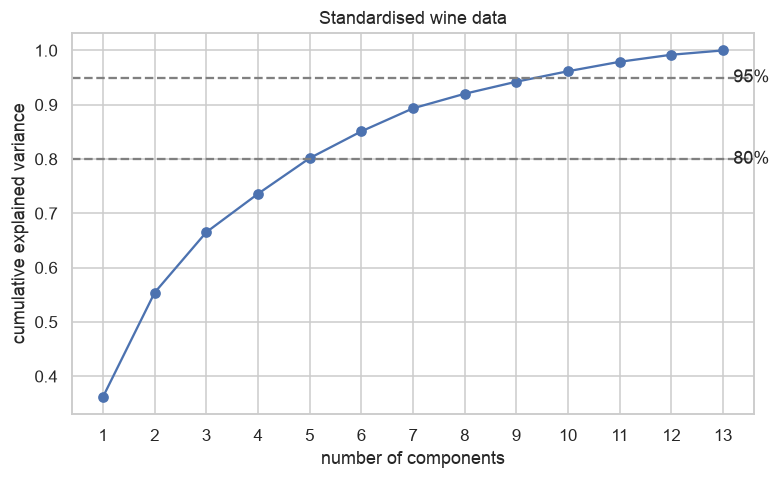

cumulative, standardised: [0.362  0.5541 0.6653 0.736  0.8016 0.851  0.8934 0.9202 0.9424 0.9617
 0.9791 0.992  1.    ]

standardised PC2 loadings, sorted by magnitude:
color_intensity                 0.5300
alcohol                         0.4840
proline                         0.3650
ash                             0.3160
magnesium                       0.3000
hue                            -0.2790
malic_acid                      0.2250
od280/od315_of_diluted_wines   -0.1640
total_phenols                   0.0650
proanthocyanins                 0.0390
nonflavanoid_phenols            0.0290
alcalinity_of_ash              -0.0110
flavanoids                     -0.0030


In [26]:
_raw_pca = PCA(random_state=SEED).fit(_X_wine)
_raw_loadings = pd.Series(_raw_pca.components_[0], index=_features)
print("unstandardised PC1 loadings, largest by magnitude:")
print(_raw_loadings.abs().sort_values(ascending=False).head(3).round(4).to_string())
print("\nvariance of each raw feature, top 3:")
print(wine[_features].var().sort_values(ascending=False).head(3).round(2).to_string())
print(f"proline share of total raw variance: {wine['proline'].var() / wine[_features].var().sum():.4%}")

fig, ax = plt.subplots(figsize=(8, 4.5))
_k = np.arange(1, len(_scaled_result["cumulative"]) + 1)
ax.plot(_k, _scaled_result["cumulative"], marker="o")
for threshold in (0.8, 0.95):
    ax.axhline(threshold, linestyle="--", color="grey")
    ax.text(13.2, threshold, f"{threshold:.0%}", va="center")
ax.set_xlabel("number of components")
ax.set_ylabel("cumulative explained variance")
ax.set_title("Standardised wine data")
ax.set_xticks(_k)
plt.show()
print("cumulative, standardised:", np.round(_scaled_result["cumulative"], 4))

_std_pca = PCA(random_state=SEED).fit(StandardScaler().fit_transform(_X_wine))
_pc2 = pd.Series(_std_pca.components_[1], index=_features)
print("\nstandardised PC2 loadings, sorted by magnitude:")
print(_pc2.reindex(_pc2.abs().sort_values(ascending=False).index).round(3).to_string())

**Your answer:**

**(a)** Without standardising, the first component explains 99.81 % of the variance, and its loading on `proline` is 0.9998 (the next biggest is `magnesium` at 0.0179). So this component is basically `proline` alone. PCA "found" it because PCA looks for the directions of largest variance, and `proline` is measured in much larger units: its variance is about 99 167, compared with 204 for magnesium and 11 for alcalinity of ash. That is 99.77 % of the total raw variance. The result shows the units, not structure in the wines. Running PCA on columns in different units makes the result depend on how each column was measured (grams against milligrams would change everything), so the columns have to be standardised first. After standardising, the first component explains only 36.20 %.

**(b)** For the standardised data, the cumulative curve reaches 55.4 % with 2 components, 80.2 % with 5, 94.2 % with 9 and 96.2 % with 10. So 80 % gives 5 components and 95 % gives 10. Neither threshold means anything special. A better procedure is to choose the number of components by performance on the actual task: put the scaler, PCA and the model (for example a classifier of the cultivar) into one pipeline, try k = 1, 2, …, 13 components, and measure the result with cross-validation on the training data only. Then pick the smallest k whose cross-validated score is close to the best one, and check it once on the test set at the end. This way the number of components is chosen by what it costs in prediction quality, not by a percentage of variance.

**(c)** "Component 2 is the strongest predictor" can be told to a winemaker only as a statement about a combination of measurements, not about a single one. Component 2 is a mix of all 13 standardised features. The largest loadings are `color_intensity` (0.53), `alcohol` (0.48), `proline` (0.37), `ash` (0.32) and `magnesium` (0.30), against `hue` (-0.28), with smaller contributions from the rest. So you can say that wines with more intense colour, more alcohol and more proline, and lower hue, tend to score high on it. You cannot say which measurement matters, or that changing one of them (e.g. raising alcohol) would change the outcome. Nothing in the component has a unit a winemaker could act on, and its direction and sign depend on the scaling and the other samples. It is also not a causal statement: it is a pattern the model found in these 178 wines, and a different dataset would give a slightly different component 2.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [27]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
    scaled = StandardScaler().fit_transform(X)
    reduced = PCA(n_components=n_pca, random_state=seed).fit_transform(scaled)
    tsne_2d = TSNE(n_components=2, perplexity=perplexity, random_state=seed, init="pca").fit_transform(reduced)
    pca_2d = PCA(n_components=2, random_state=seed).fit(scaled)
    return {
        "pca_2d": pca_2d.transform(scaled),
        "tsne_2d": tsne_2d,
        "explained_2d": float(pca_2d.explained_variance_ratio_.sum()),
        "reduced": reduced,
    }

In [28]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [29]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

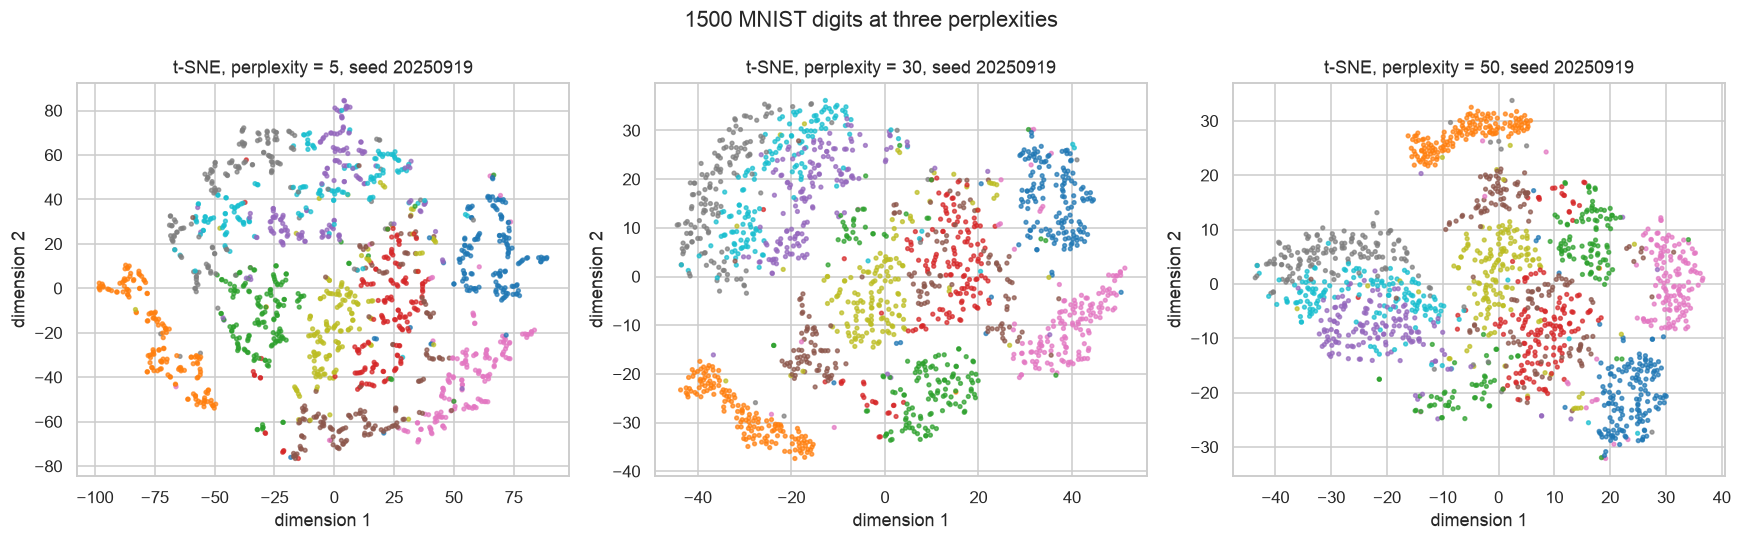

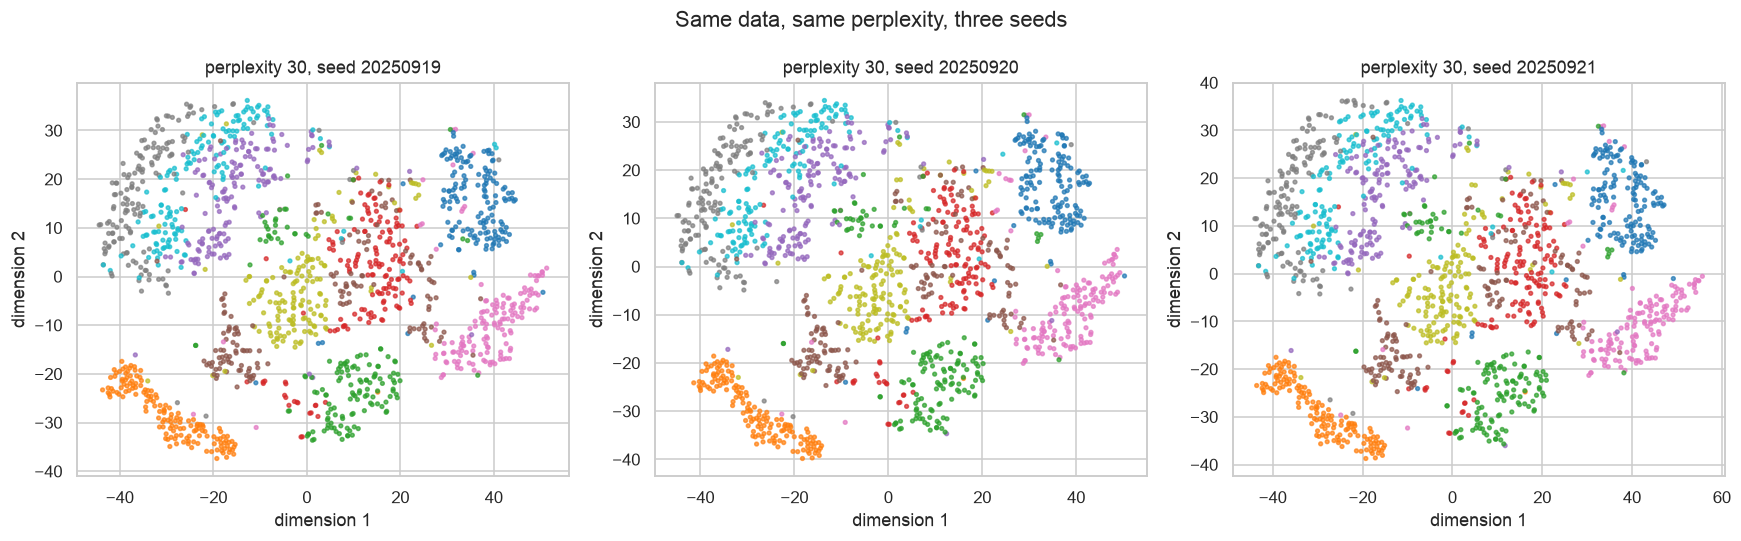

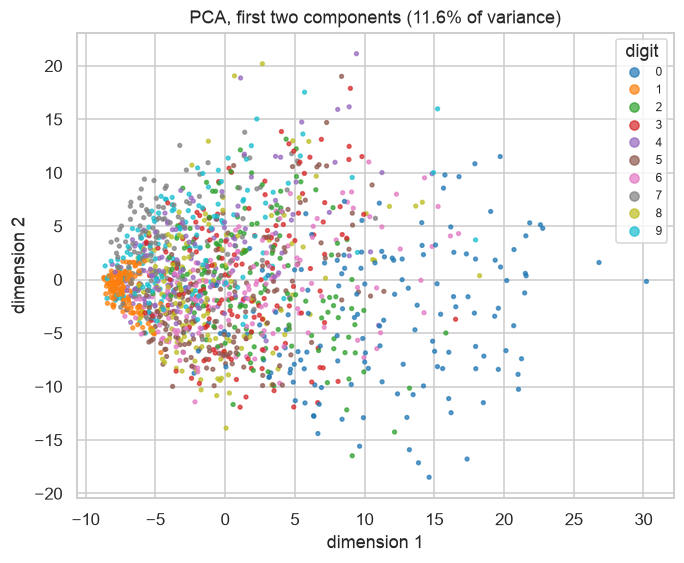

two PCA components carry 11.63% of the variance of the 1500 digits

5-fold accuracy of a 5-NN classifier on each 2-D map (how well digits separate):
  t-SNE perplexity 5           0.8720
  t-SNE perplexity 30          0.8733
  t-SNE perplexity 50          0.8660
  t-SNE perplexity 30 seed 20250920 0.8733
  t-SNE perplexity 30 seed 20250921 0.8647
  PCA 2-D                      0.3093
  PCA 50-D (t-SNE input)       0.8827
max |coordinate difference| seed 20250919 vs 20250920: 34.51
max |coordinate difference| seed 20250919 vs 20250921: 35.47


In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

_full = {p: project_two_ways(pixels, perplexity=p, seed=SEED) for p in (5, 30, 50)}
_seeds = {s: project_two_ways(pixels, perplexity=30, seed=s)["tsne_2d"] for s in (SEED + 1, SEED + 2)}

def _scatter(ax, points, title):
    ax.scatter(points[:, 0], points[:, 1], c=digit_labels, cmap="tab10", s=6, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("dimension 1")
    ax.set_ylabel("dimension 2")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (p, result) in zip(axes, _full.items()):
    _scatter(ax, result["tsne_2d"], f"t-SNE, perplexity = {p}, seed {SEED}")
fig.suptitle("1500 MNIST digits at three perplexities")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
_scatter(axes[0], _full[30]["tsne_2d"], f"perplexity 30, seed {SEED}")
for ax, (s, points) in zip(axes[1:], _seeds.items()):
    _scatter(ax, points, f"perplexity 30, seed {s}")
fig.suptitle("Same data, same perplexity, three seeds")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.5))
_scatter(ax, _full[30]["pca_2d"], f"PCA, first two components ({_full[30]['explained_2d']:.1%} of variance)")
sc = ax.collections[0]
ax.legend(*sc.legend_elements(), title="digit", fontsize=8, loc="best")
plt.show()

print(f"two PCA components carry {_full[30]['explained_2d']:.2%} of the variance of the 1500 digits")
print("\n5-fold accuracy of a 5-NN classifier on each 2-D map (how well digits separate):")
_maps = {f"t-SNE perplexity {p}": r["tsne_2d"] for p, r in _full.items()}
_maps.update({f"t-SNE perplexity 30 seed {s}": pts for s, pts in _seeds.items()})
_maps["PCA 2-D"] = _full[30]["pca_2d"]
_maps["PCA 50-D (t-SNE input)"] = _full[30]["reduced"]
for name, points in _maps.items():
    score = cross_val_score(KNeighborsClassifier(n_neighbors=5), points, digit_labels, cv=5).mean()
    print(f"  {name:28s} {score:.4f}")
for s, points in _seeds.items():
    print(f"max |coordinate difference| seed {SEED} vs {s}: {np.abs(_full[30]['tsne_2d'] - points).max():.2f}")

**Your answer:**

**(a)** At perplexity 5 the picture is fragmented. Most digits are broken into several small islands and strands (e.g. the 2s and 3s form many little pieces spread over the map), and there are many small groups with gaps between them. At perplexity 30 each digit forms roughly one cluster, and some clusters touch (4, 7 and 9 sit together in the top left, and 3, 5 and 8 in the middle). At perplexity 50 the clusters become rounder and more compact, and neighbouring digits merge into bigger regions (4/7/9 is one continent). Perplexity roughly sets how many neighbours each point tries to stay close to. A small value only looks at about 5 nearest neighbours, so it keeps very local structure and breaks the classes apart. A large value uses a larger neighbourhood (about 50 points), so similar classes merge. Separation measured by a 5-NN classifier on the 2-D map is similar for all three (0.872, 0.873 and 0.866), so the classes are equally real in all of them. Only the picture changes.

**(b)** The two runs with different seeds at perplexity 30 also differ. The layout is similar, but individual points move by up to 34.5 and 35.5 units, and cluster positions and shapes change a bit (the 5-NN scores were 0.873 and 0.865). t-SNE is seed-dependent because it solves an optimisation problem with no single exact solution. It starts from an initial layout and moves the points step by step with gradient descent, and the method involves randomness, so it ends in one of many local optima, and the result depends on the random state. A t-SNE figure published without a stated `random_state` cannot be reproduced. Nobody, including the author, can get the same picture again, and a reader cannot tell which details are real and which are specific to that run.

**(c)** The PCA projection with two components carries only 11.63 % of the variance, and most of the digits overlap in one cloud (5-NN accuracy on it is 0.309, against 0.873 for t-SNE). Even so, from the t-SNE picture I still cannot conclude:
1. anything from the axes: "dimension 1" and "dimension 2" have no meaning or units, unlike principal components;
2. anything from the distances between clusters: two digit clusters being far apart on the map does not mean they are more different than two clusters that are close;
3. anything from cluster sizes or density: t-SNE expands sparse regions and compresses dense ones, so a bigger blob is not a more variable digit.

(It also has no `transform`, so new images cannot be placed on the map.) As input to a clustering algorithm I would use the PCA output, preferably the 50-component reduction rather than the 2-D picture. PCA is a real linear projection with a `transform` that can be reused on new data, and its distances keep a meaning (5-NN on the 50 PCA components gives 0.883, which is even better than any 2-D t-SNE map). Clustering on t-SNE coordinates would mostly find the clusters that the perplexity and the seed created, and the result could not be applied to new data.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [31]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    workingday_names = {0: "weekend or holiday", 1: "working day"}
    weather_names = {1: "1 clear, partly cloudy", 2: "2 mist", 3: "3 light rain or snow", 4: "4 heavy rain or snow"}
    by_workingday = bikes_frame.groupby(["hr", "workingday"])["cnt"].mean().unstack()
    by_weather = bikes_frame.groupby(["hr", "weathersit"])["cnt"].mean().unstack()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
    for value in by_workingday.columns:
        axes[0].plot(by_workingday.index, by_workingday[value], marker="o", label=workingday_names[value])
    for value in by_weather.columns:
        axes[1].plot(by_weather.index, by_weather[value], marker="o", label=weather_names[value])
    for ax, title in zip(axes, ["Working days against weekends and holidays", "By weather situation"]):
        ax.set_xlabel("hour of day")
        ax.set_ylabel("mean rentals per hour")
        ax.set_title(title)
        ax.set_xticks(range(0, 24, 2))
        ax.legend()
    fig.suptitle("Hourly bicycle demand, Washington D.C. 2011-2012")
    fig.tight_layout()
    return fig, axes

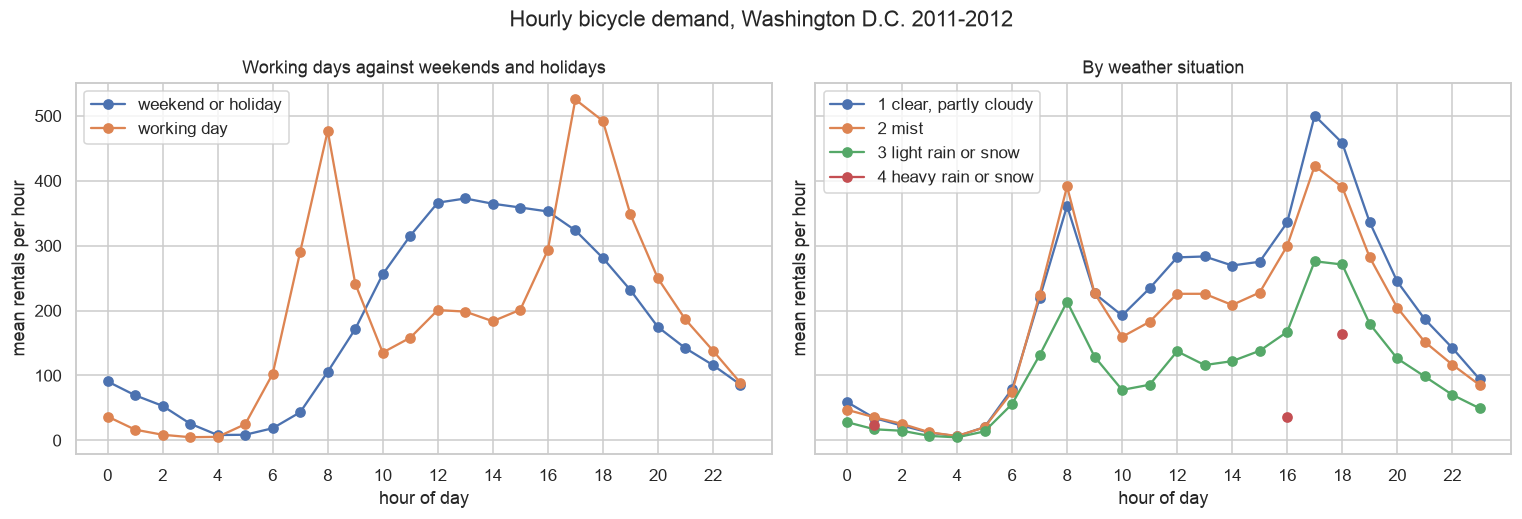

Task 11 passed.


In [32]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

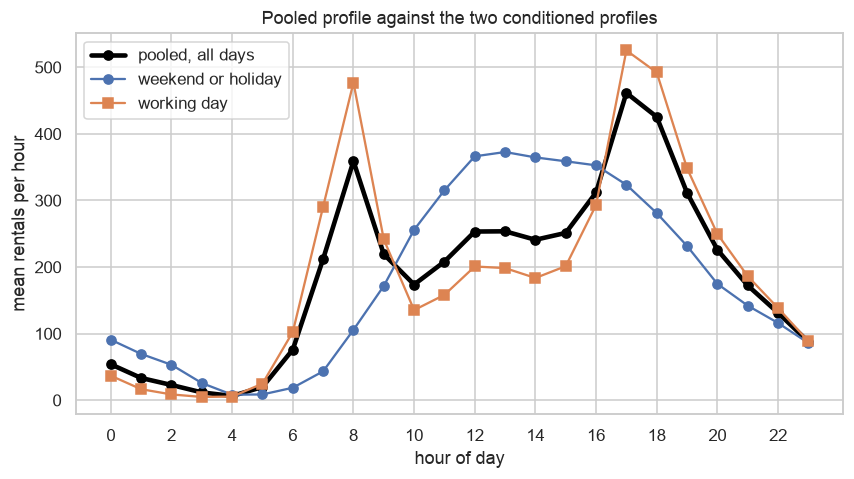

share of rows that are working days: 0.6827
     pooled  weekend/holiday  working day
hr                                       
3   11.7000          25.8000       4.9000
8  359.0000         105.7000     477.0000
12 253.3000         366.3000     200.8000
13 253.7000         372.7000     198.4000
17 461.5000         323.5000     525.3000
18 425.5000         281.1000     492.2000

peak hour: pooled 17 | weekend/holiday 13 | working day 17
8:00 as a share of the daily peak: pooled 77.80%, weekend 28.35%, working 90.81%
13:00 vs 8:00: pooled 0.71, weekend 3.53, working 0.42


In [33]:
_pooled = bikes.groupby("hr")["cnt"].mean()
_by_wd = bikes.groupby(["hr", "workingday"])["cnt"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(_pooled.index, _pooled.values, marker="o", color="black", linewidth=3, label="pooled, all days")
ax.plot(_by_wd.index, _by_wd[0], marker="o", label="weekend or holiday")
ax.plot(_by_wd.index, _by_wd[1], marker="s", label="working day")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean rentals per hour")
ax.set_title("Pooled profile against the two conditioned profiles")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.show()

print("share of rows that are working days:", round(bikes["workingday"].mean(), 4))
print(pd.DataFrame({"pooled": _pooled, "weekend/holiday": _by_wd[0], "working day": _by_wd[1]})
      .loc[[3, 8, 12, 13, 17, 18]].round(1).to_string())
print("\npeak hour: pooled", _pooled.idxmax(), "| weekend/holiday", _by_wd[0].idxmax(), "| working day", _by_wd[1].idxmax())
print(f"8:00 as a share of the daily peak: pooled {_pooled[8] / _pooled.max():.2%}, "
      f"weekend {_by_wd.loc[8, 0] / _by_wd[0].max():.2%}, working {_by_wd.loc[8, 1] / _by_wd[1].max():.2%}")
print(f"13:00 vs 8:00: pooled {_pooled[13] / _pooled[8]:.2f}, weekend {_by_wd.loc[13, 0] / _by_wd.loc[8, 0]:.2f}, "
      f"working {_by_wd.loc[13, 1] / _by_wd.loc[8, 1]:.2f}")

**Your answer:**

**(a)** The pooled profile (all days together) has two peaks at 8:00 (359 rentals/hour) and 17:00 (461.5), with a middle-of-the-day level of about 253 at 12:00 and 13:00. 68.3 % of the rows are working days, so the pooled line mostly follows the working-day line, but it also has a noticeable midday level. From the pooled figure you could say, for example, "there is a morning commuter peak at 8:00 that is about 78 % of the daily peak, and demand at midday stays at about 70 % of the morning peak level" (13:00 / 8:00 = 0.71). That is false for both groups. On working days the morning peak is almost as high as the evening one (477 at 8:00, which is 91 % of the 525 peak), and midday demand falls to only 42 % of the 8:00 level (198). On weekends and holidays there is no morning peak at all: 8:00 has only 106, 28 % of that group's peak, and demand is highest around 13:00 (373), 3.5 times the 8:00 value. So the pooled curve describes a "typical day" that never happens: it mixes two different kinds of days, a commuting pattern and a leisure pattern.

**(b)** This is the same phenomenon as Simpson's paradox in Practice 2 §12: an aggregate taken over a mixture of groups can show a pattern that is not present in, or even contradicts, the groups themselves, because a third variable (here `workingday`) changes the relationship. The general rule is that before reporting an aggregate, you should check whether there is a variable that splits the data into groups that behave differently. If there is, you should condition on it and report the groups separately, or at least next to the aggregate, instead of only the pooled number.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64

meaningless but allowed before fixing: mean season 2.5016 | mean weekday 3.0037 | mean weathersit 1.4253
after astype('category'): report['season'].mean() -> TypeError 'Categorical' with dtype category does not support operation 'mean'
dteday: str -> datetime64[us]

        temp_celsius  atemp_celsius  humidity_percent  windspeed_kmh
count   17,379.0000    17,379.0000       17,379.0000    17,379.0000
mean        20.3800        23.7900           62.7200        12.7400
std          7.8900         8.5900           19.2900         8.2000
min          0.8200         0.0000            0.0000         0.0000
25%         13.94

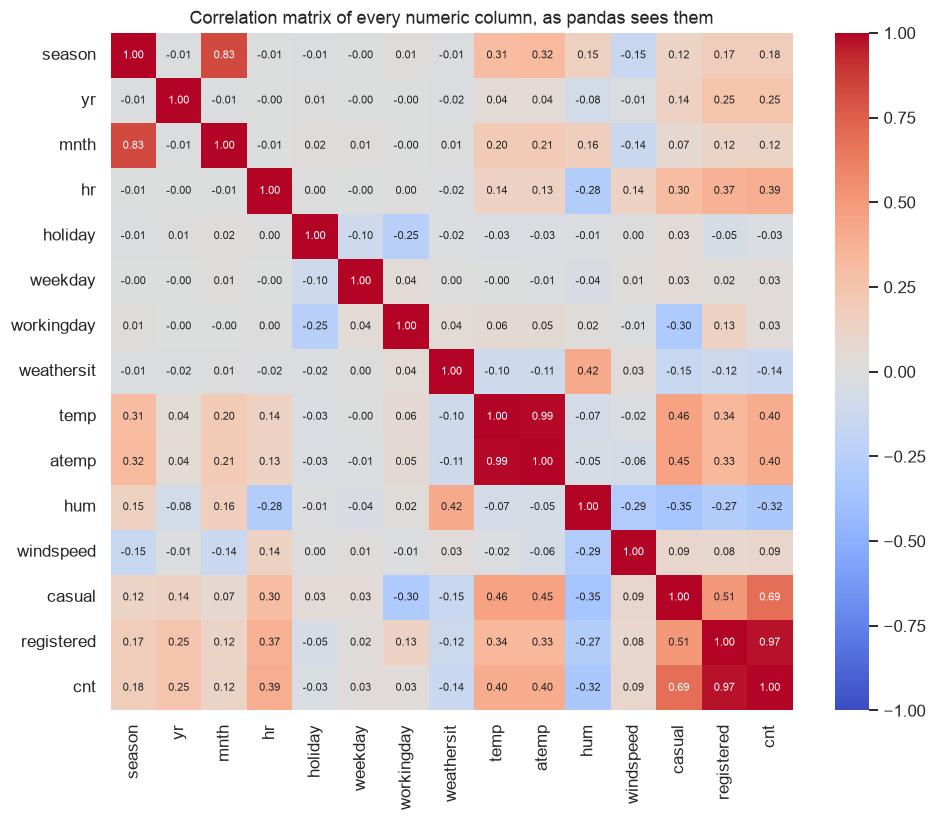

corr(temp, atemp) = +0.9877
corr(registered, cnt) = +0.9722
corr(casual, cnt) = +0.6946
corr(hr, cnt) = +0.3941
corr(weathersit, cnt) = -0.1424
corr(season, cnt) = +0.1781
corr(mnth, season) = +0.8304
corr(instant, cnt) = +0.2784
corr(yr, cnt) = +0.2505

mean cnt by season: {1: 111.1, 2: 208.3, 3: 236.0, 4: 198.9}
mean cnt by weathersit: {1: 204.9, 2: 175.2, 3: 111.6, 4: 74.3} | rows per weathersit: {1: 11413, 2: 4544, 3: 1419, 4: 3}
exact identity casual + registered == cnt: True
registered share of all rentals: 81.17%
mean cnt by yr: {0: 143.8, 1: 234.7}


In [34]:
report = bikes.copy()
print(report.dtypes.to_string())
print("\nmeaningless but allowed before fixing: mean season", round(report["season"].mean(), 4),
      "| mean weekday", round(report["weekday"].mean(), 4), "| mean weathersit", round(report["weathersit"].mean(), 4))

categorical = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]
report[categorical] = report[categorical].astype("category")
try:
    report["season"].mean()
except TypeError as exc:
    print("after astype('category'): report['season'].mean() ->", type(exc).__name__, str(exc)[:70])

report["dteday"] = pd.to_datetime(report["dteday"])
print("dteday:", bikes["dteday"].dtype, "->", report["dteday"].dtype)

report["temp_celsius"] = report["temp"] * 41
report["atemp_celsius"] = report["atemp"] * 50
report["humidity_percent"] = report["hum"] * 100
report["windspeed_kmh"] = report["windspeed"] * 67
physical = ["temp_celsius", "atemp_celsius", "humidity_percent", "windspeed_kmh"]
print("\n", report[physical].describe().round(2).to_string())
print("\nmonths in each season code:", {k: sorted(v.tolist()) for k, v in bikes.groupby("season")["mnth"].unique().items()})
print("mean temperature by season code, deg C:", report.groupby("season", observed=True)["temp_celsius"].mean().round(1).to_dict())
print("rows with humidity exactly 0:", int((report["hum"] == 0).sum()),
      "on dates", sorted(report.loc[report["hum"] == 0, "dteday"].dt.date.astype(str).unique()))
print("rows with windspeed exactly 0:", int((report["windspeed"] == 0).sum()),
      f"({(report['windspeed'] == 0).mean():.2%});  next smallest windspeed:",
      round(report.loc[report["windspeed"] > 0, "windspeed_kmh"].min(), 2), "km/h")
print(f"atemp - temp, in degrees: min {(report['atemp_celsius'] - report['temp_celsius']).min():.2f}, "
      f"max {(report['atemp_celsius'] - report['temp_celsius']).max():.2f}")
_odd_atemp = report.loc[(report["atemp_celsius"] - report["temp_celsius"]).abs() > 15,
                        ["dteday", "hr", "temp_celsius", "atemp_celsius", "humidity_percent"]]
print("rows where apparent and real temperature differ by more than 15 degrees:", len(_odd_atemp),
      "| dates:", sorted(_odd_atemp["dteday"].dt.date.astype(str).unique()))
_aug17 = report[report["dteday"] == "2012-08-17"]
print(f"2012-08-17: {len(_aug17)} rows, atemp values {sorted(_aug17['atemp_celsius'].round(2).unique().tolist())}, "
      f"temp from {_aug17['temp_celsius'].min():.2f} to {_aug17['temp_celsius'].max():.2f}")
print(_odd_atemp.head(5).to_string(index=False))

days = pd.date_range(report["dteday"].min(), report["dteday"].max(), freq="D")
expected = len(days) * 24
print(f"\n{len(days)} days x 24 = {expected} hours expected, {len(report)} present, {expected - len(report)} missing")
print("duplicate (date, hour) rows:", int(report.duplicated(["dteday", "hr"]).sum()))
hours_per_day = report.groupby("dteday").size()
print("days with fewer than 24 rows:", int((hours_per_day < 24).sum()),
      "| distribution of rows per incomplete day:", hours_per_day[hours_per_day < 24].value_counts().sort_index().to_dict())
present_by_hour = report.groupby("hr", observed=True).size()
print("missing rows by hour of day:", (len(days) - present_by_hour).to_dict())
print("days missing the most hours:")
print(hours_per_day.nsmallest(6).to_string())

numeric = bikes.drop(columns=["instant", "dteday"])
corr = numeric.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation matrix of every numeric column, as pandas sees them")
plt.show()
for a, b in [("temp", "atemp"), ("registered", "cnt"), ("casual", "cnt"), ("hr", "cnt"),
             ("weathersit", "cnt"), ("season", "cnt"), ("mnth", "season"), ("instant", "cnt"), ("yr", "cnt")]:
    source = bikes
    print(f"corr({a}, {b}) = {source[a].corr(source[b]):+.4f}")
print("\nmean cnt by season:", bikes.groupby("season")["cnt"].mean().round(1).to_dict())
print("mean cnt by weathersit:", bikes.groupby("weathersit")["cnt"].mean().round(1).to_dict(),
      "| rows per weathersit:", bikes["weathersit"].value_counts().sort_index().to_dict())
print("exact identity casual + registered == cnt:", bool((bikes["casual"] + bikes["registered"] == bikes["cnt"]).all()))
print(f"registered share of all rentals: {bikes['registered'].sum() / bikes['cnt'].sum():.2%}")
print("mean cnt by yr:", bikes.groupby("yr")["cnt"].mean().round(1).to_dict())

**Your write-up:**

**1. Types.** pandas reads 15 of the 17 columns as `int64` or `float64`, `dteday` as a string, and `instant` as an integer. Eight of the integer columns are category codes and not quantities: `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday` and `weathersit`. With the inferred types, pandas lets you compute meaningless things like a mean season of 2.5016, a mean weekday of 3.0037 and a mean weather situation of 1.4253. After converting them with `astype("category")`, `report["season"].mean()` raises a `TypeError` ("'Categorical' with dtype category does not support operation 'mean'"). `dteday` was parsed with `pd.to_datetime` (str → datetime64). `instant` is only a row number and should not be a feature. I also found something that looks wrong in the documentation: the README says season 1 = spring and 4 = winter, but in the data season 1 covers months 1, 2, 3 and 12, with an average temperature of 12.3 °C (the coldest of the four), while season 4 covers months 9 to 12 at 17.3 °C. So season 1 is in fact winter and season 4 is autumn. This matters when interpreting results, though for a one-hot encoded model the labels do not change anything. (`weathersit` is ordered by severity, so it is ordinal rather than nominal. Category 4 has only 3 rows.)

**2. Units.** Using the documented divisors (41 °C, 50 °C, 100 %, 67 km/h): temperature ranges from 0.82 to 41.0 °C (mean 20.38), apparent temperature from 0.0 to 50.0 °C, humidity from 0 to 100 % (mean 62.7) and wind speed from 0 to 57 km/h (mean 12.7). These ranges are plausible for Washington D.C. overall. But three things look wrong. (a) 22 rows have a relative humidity of exactly 0 %, all on one day (2011-03-10). That is physically impossible outdoors, so it has to be a sensor or recording failure, and these values should be set to missing. (b) On 2012-08-17 the apparent temperature is exactly 12.12 °C for all 24 hours while the real temperature is 25.4 to 35.3 °C. These are the 15 rows where the two differ by more than 15 degrees, and the minimum of `atemp - temp` (-23.14 degrees) is from this day. It is a stuck value, so the whole day's `atemp` is wrong. (c) 2180 rows (12.54 %) have a wind speed of exactly 0, and the next smallest value is 6.0 km/h, with nothing in between. So 0 is probably "calm, below what the instrument reports" or "not recorded", not a real measurement of zero. This is misleading rather than wrong, but it should not be treated as a normal number.

**3. The date.** The data covers 731 days from 2011-01-01 to 2012-12-31, which should give 731 × 24 = 17 544 hourly rows. There are 17 379, so 165 hours are missing (there are no duplicate date-hour pairs). The missing rows are not random. 62 of the 76 incomplete days miss only one hour, and the missing hours are concentrated at night, at hours 2, 3 and 4 (16, 34 and 34 missing rows), exactly when demand is close to zero. That suggests hours with no rentals were simply not written down, so a missing row most likely means "0 rentals", not "unknown". There are also a few days with most of the hours missing: 2012-10-29 has only 1 row, 2012-10-30 has 11, 2011-01-27 has 8, 2011-01-18 has 12, 2011-01-26 has 16 and 2011-08-28 has 17. Some of these dates coincide with known severe weather in D.C. (hurricane Sandy at the end of October 2012, hurricane Irene at the end of August 2011, and a snowstorm in late January 2011), so the system was probably shut down. In both cases the missing hours are linked to low demand. Dropping them makes the hourly averages slightly too high, and any time-series feature (such as lags) has to be built on a complete hourly index.

**4. A correlation you should not compute.** In the correlation matrix of all numeric columns, several entries are meaningless or misleading.
- `corr(hr, cnt) = +0.39`: `hr` is a category with a non-monotonic effect (peaks at 8:00 and 17:00, low at night and around 10:00), and hour 23 is next to hour 0. A linear coefficient on the integer code does not measure how strongly the hour affects demand, which is actually the strongest effect in the data.
- `corr(season, cnt) = +0.18`: the mean `cnt` by season is 111, 208, 236 and 199, which is not monotonic, and the codes 1 to 4 are arbitrary (and mislabelled, as noted above), so reordering the codes would change the number.
- `corr(weathersit, cnt) = -0.14` has the right sign, because the codes are ordered by severity, but it assumes the steps between categories are equal and it is dominated by the 11 413 clear-weather rows (category 4 has 3 rows).
- `corr(registered, cnt) = +0.97` and `corr(casual, cnt) = +0.69` are true but tautological: `cnt` is exactly their sum (checked: `casual + registered == cnt` for every row, and registered users account for 81.2 % of all rentals).
- `corr(temp, atemp) = +0.99` and `corr(mnth, season) = +0.83` are also true by construction: they show redundancy, not a discovery.
- `corr(instant, cnt) = +0.28` looks like a feature but is only the time trend: demand grew from 143.8 per hour in 2011 to 234.7 in 2012.

The first two are the ones that are actually wrong, because they describe the arbitrary coding, not the data.

**5. Leakage.** `casual` and `registered` add up to `cnt` exactly, so using them as features to predict `cnt` gives a near-perfect model that is useless. When you want to predict the demand for an hour, you do not know yet how many casual and registered users will rent bikes in that hour. Knowing them means already knowing the answer. A realistic task where they would be legitimate is forecasting: predicting the number of rentals in the next hour (or the next day) using `casual` and `registered` from the previous hours as lag features. Those counts are known at the time of the prediction, and the split between casual and registered users carries real information (for example, a high share of casual users indicates a leisure day). Another one would be predicting the split itself, e.g. the share of casual users from weather and calendar features.

**6. Recommendation.** For a model of hourly demand (`cnt`) I would use `hr` as a category (or one-hot encoded), because its effect is not monotonic. I would also use `workingday`, `holiday` and `weekday`, since the daily profile is completely different on working days, and `season` or `mnth` as categories for the seasonal effect. I would keep `yr` for the growth trend (143.8 → 234.7) and `weathersit` as an ordinal feature, with category 4 (3 rows) merged into 3. From the weather columns I would use `temp`, `hum` and `windspeed`: humidity with the 22 zero values of 2011-03-10 set to missing and filled, and wind speed with a flag for the 12.5 % zeros. I would exclude `casual` and `registered` (target leakage), `instant` (row number, its trend is already covered by `yr`), raw `dteday` (its useful parts are already in `yr`, `mnth` and `weekday`), and `atemp`, which is almost a copy of `temp` (r = 0.99) and has a broken day. The findings that actually change the modelling are the leakage, treating `hr` and the other codes as categories, dropping `atemp`, and cleaning humidity. The mislabelled seasons and the missing night hours are worth documenting, but they would not change which columns go into the model.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.